<a href="https://colab.research.google.com/github/roger-teixeira-batista/deteccao_de_fraudes_em_cartoes_de_credito/blob/main/Projeto_Detec%C3%A7%C3%A3o_de_Fraude_em_Cart%C3%B5es_de_Cr%C3%A9dito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Fraudes em Cartões de Crédito

Neste projeto, iremos abordar o problema das fraudes em cartões de crédito, uma das principais preocupações das instituições financeiras como bancos e *fintechs*. Apenas no Brasil, cerca de 12,1 milhões de pessoas já foram vítimas de algum tipo de fraude financeira no último ano. Traduzindo em valores, os golpes financeiros ultrapassaram a cifra de R$ 1,8 bilhão de prejuízo por ano para os últimos 12 meses.

Dentra essas fraudes, aquelas envolvendo cartões de crédito são de grande relevância uma vez que a sua não-detecção acaretará em prejuízos consideráveis, tanto para o consumidor quanto para a instituição financeira.

Um outro fator a ser considerado é a quantidade de falsos positivos, ou seja, aquelas vezes em que você tentou fazer uma compra e teve seu cartão bloqueado preventivamente - o que provavelmente gerou estresse e constrangimento.

Por todos esses motivos, o investimento na área de detecção de fraudes por meio de Inteligência Artificial vem crescendo a cada ano, representando uma grande oportunidade em *Data Science*.

Dispondo de grandes volumes de dados como base histórica, um algoritmo de machine learning apenas um pouco melhor que os anteriores já representa uma economia de milhões de Reais. E esse é o desafio, aprimorar cada vez mais o uso de algoritmos visando inibir ou evitar transações fraudulentas.

## Importando os Dados

Os dados que usaremos neste projeto foram disponibilizados por algumas empresas européias de cartão de crédito. O *dataset* representa as operações financeiras que aconteceram no período de dois dias, onde foram classificadas 492 fraudes em meio a quase 290 mil transações.

Como você pode notar, este é um conjunto de dados extremamente desbalanceado, onde as fraudes representam apenas 0,17% do total.

Outro detalhe interessante é que as *features* são todas numéricas, e foram descaracterizadas (por problemas ligados à privacidade e segurança). Assim, os nomes das colunas são representados por $[V1, V2, V3 \dots, V28]$

[Na página original dos dados](https://www.kaggle.com/mlg-ulb/creditcardfraud), também é informado que as variáveis passaram por uma transformação conhecida como Análise de Componentes Principais (*Principal Component Analysis* - PCA).

A PCA permite a redução da dimensionalidade enquanto mantém o maior número possível de informações. Para conseguir isso, o algoritmo encontra um conjunto novo de recursos - os chamados **componentes**.

Esses componentes são em número menor or igual às variáveis originais. No caso deste projeto, os componentes achados pela transformação da PCA são as próprias colunas $[V1, V2, V3 \dots, V28]$.

In [40]:
# importar os pacotes necessários
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler

Para facilitar a aquisição dos dados, criei um *link* com acesso direto ao `csv`. Com isso, basta importar o conjunto de dados usando o método `pd.read_csv()`.

In [2]:
file_path = "https://www.dropbox.com/s/b44o3t3ehmnx2b7/creditcard.csv?dl=1"

# importar os dados para um dataframe
df = pd.read_csv(file_path)

Com os dados importados para dentro de uma estrutura *Dataframe* - e não havendo a necessidade de mais nenhum ajuste ou configuração nesta etapa, pode-se iniciar uma análise exploratória dos dados a fim de preparar um modelo de *Machine Learning*.

## Análise Exploratória

### Observar as primeiras 5 entradas

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Apenas olhando as cinco primeiras entradas é possível tirar algumas conclusões:

* As 5 primeiras entradas permitem entender como a transformação PCA deixou as *features* descaracterizadas (anônimas) e em valores numéricos.

* As colunas `Time` e `Amount` foram preservadas, mantendo seu valor original.

* A variável alvo está representada na coluna `Class`, onde:
    * **0:** Transação normal; e
    * **1:** Transação fraudulenta;

### Resumo estatístico do DataFrame

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Verificando abaixo o resumo estatístico, por meio do método `describe()`, podemos confirmar que as variáveis relativas aos componentes principais (transformação PCA) não têm nenhuma discrepância aparente, bem como a coluna `Time`.

Em relação à variável `Amount`, nota-se que o valor médio de transações (considerando ambas as classes) é 88.34, mediana igual a 22.00 e desvio padrão de 250.12. Atingindo o valor máximo de 25691.16, a maioria das transações financeiras é composta em sua maioria por quantias menores - como esperado.

### Verificação de valores ausentes

In [5]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Nenhum valor faltante no dataset.

### Gráfico de barra para verificação de balanceamento no dataset

In [6]:
balanceamento = (df['Class'].value_counts() / df.shape[0]) * 100

balanceamento

,count
Class,
0,99.827251
1,0.172749


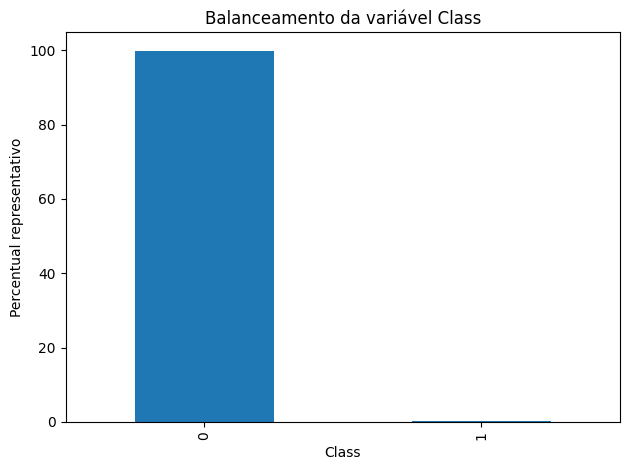

In [7]:
fig, ax = plt.subplots()

balanceamento.plot(kind='bar', ax=ax)

ax.set_title('Balanceamento da variável Class')
ax.set_xlabel('Class')
ax.set_ylabel('Percentual representativo')

plt.tight_layout()

Cerca de **99.82%** do dataset **não são fraudes**, ao passo que somente **0.17%** do dataset representam **transações fraudulentas**.
Daí o desbalanceamento mencionado anteriormente no texto.

### Histogramas para a variável `Time`

### Com fraude

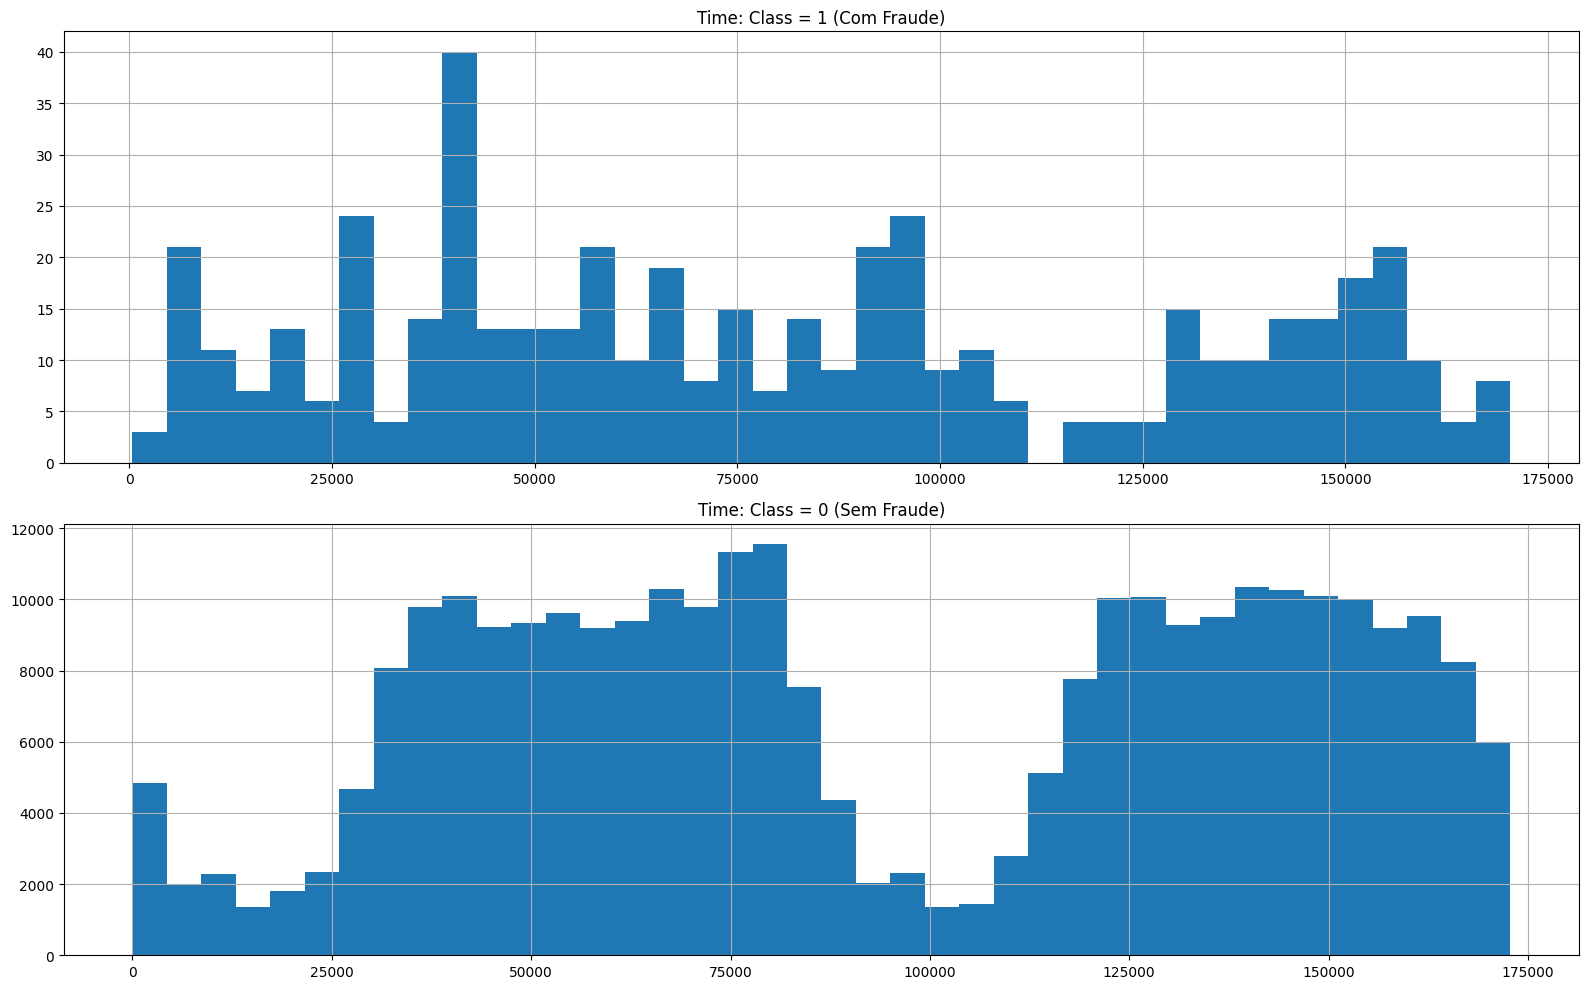

In [20]:
time_com_fraude = df.loc[df['Class'] == 1, 'Time']
time_sem_fraude = df.loc[df['Class'] == 0, 'Time']

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 10))

num_bins = 40

time_com_fraude.hist(ax=ax1, bins=num_bins)
time_sem_fraude.hist(ax=ax2, bins=num_bins)

ax1.set_title('Time: Class = 1 (Com Fraude)')
ax2.set_title('Time: Class = 0 (Sem Fraude)')

plt.tight_layout();

Plotou-se também dois gráficos a fim de comparar as distribuições das 2 classes ao longo da dimensão tempo (`Time`). No entanto, não foi identificada nenhum informação a partir das distribuições de frequência abaixo.

### Histogramas para a variável `Amount`

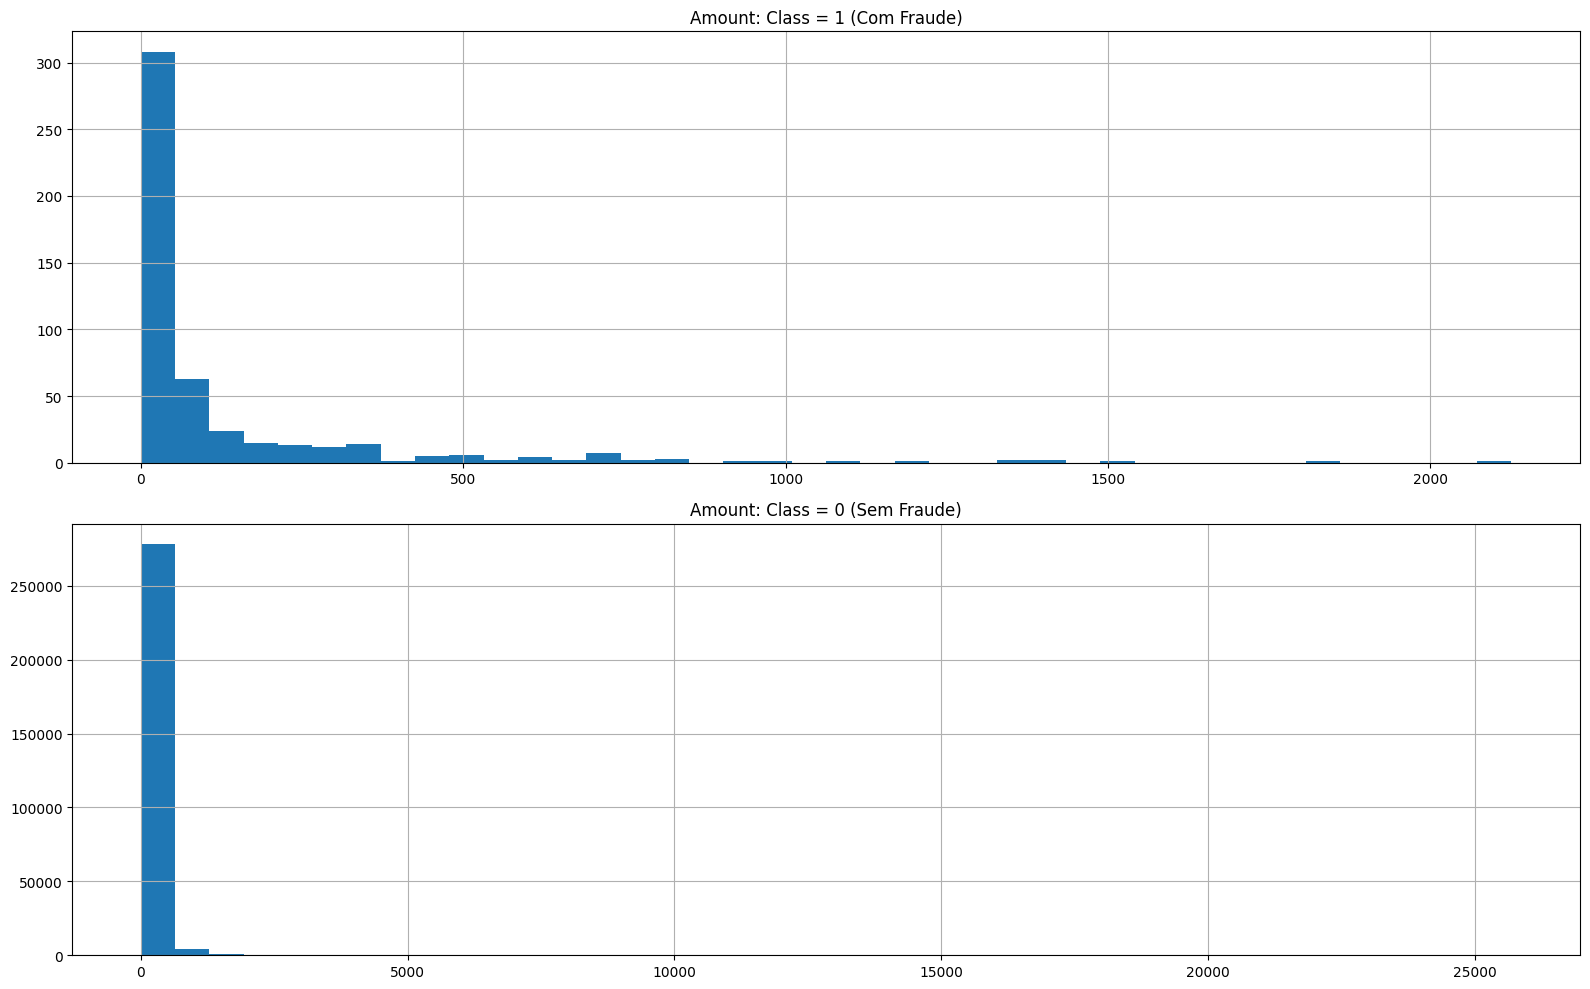

In [22]:
amount_com_fraude = df.loc[df['Class'] == 1, 'Amount']
amount_sem_fraude = df.loc[df['Class'] == 0, 'Amount']

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 10))

num_bins=40

amount_com_fraude.hist(ax=ax1, bins=num_bins)
amount_sem_fraude.hist(ax=ax2, bins=num_bins)

ax1.set_title('Amount: Class = 1 (Com Fraude)')
ax2.set_title('Amount: Class = 0 (Sem Fraude)')

plt.tight_layout();

Quando analisamos o **gráfico 1**, percebemos que temos uma alta concentração de fraudes entre 0 e um pouco menos de 250, mas temos outras faixas de valores.

Quando analisamos o **gráfico 2**, percebemos que a única faixa de valores presente nas transações sem fraude são valores entre 0 e um pouco menos de 2500.

A conclusão que podemos tirar ao olharmos os dois gráficos é que as transações constumam ser em quantias mais baixas, havendo algumas variações de quantias quando as transações são fraudulentas.

### Boxplot para a variável `Amount` quando há fraude

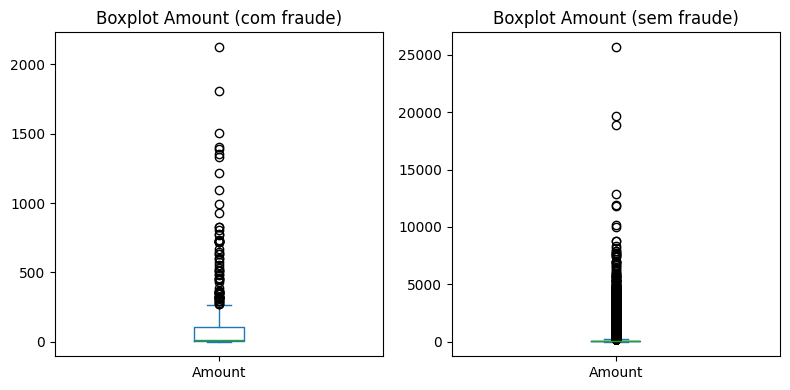

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

amount_com_fraude.plot(kind='box', ax=ax[0])
amount_sem_fraude.plot(kind='box', ax=ax[1])

ax[0].set_title('Boxplot Amount (com fraude)')
ax[1].set_title('Boxplot Amount (sem fraude)')

plt.tight_layout();

Seguindo a análise exploratória, plotou-se os *boxplots* para ver se há alguma diferença no padrão transações em relação à dimensão `Amount`.

De uma maneira geral, percebe-se uma distribuição diferente para as duas classes, o que provavelmente irá contribuir para o treinamento do modelo de *machine learning*.

In [89]:
df[df['Class'] == 1]['Amount'].describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


As informações estatísticas para `df.Class == 1` mostram que a sua média exata está em 122.21 e a mediana em 9.25.

In [90]:
df[df['Class'] == 0]['Amount'].describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


As informações estatísticas para `df.Class == 0` mostram que a sua média exata está em 88.29 e a mediana em 22.00.

### Gráficos de densidade

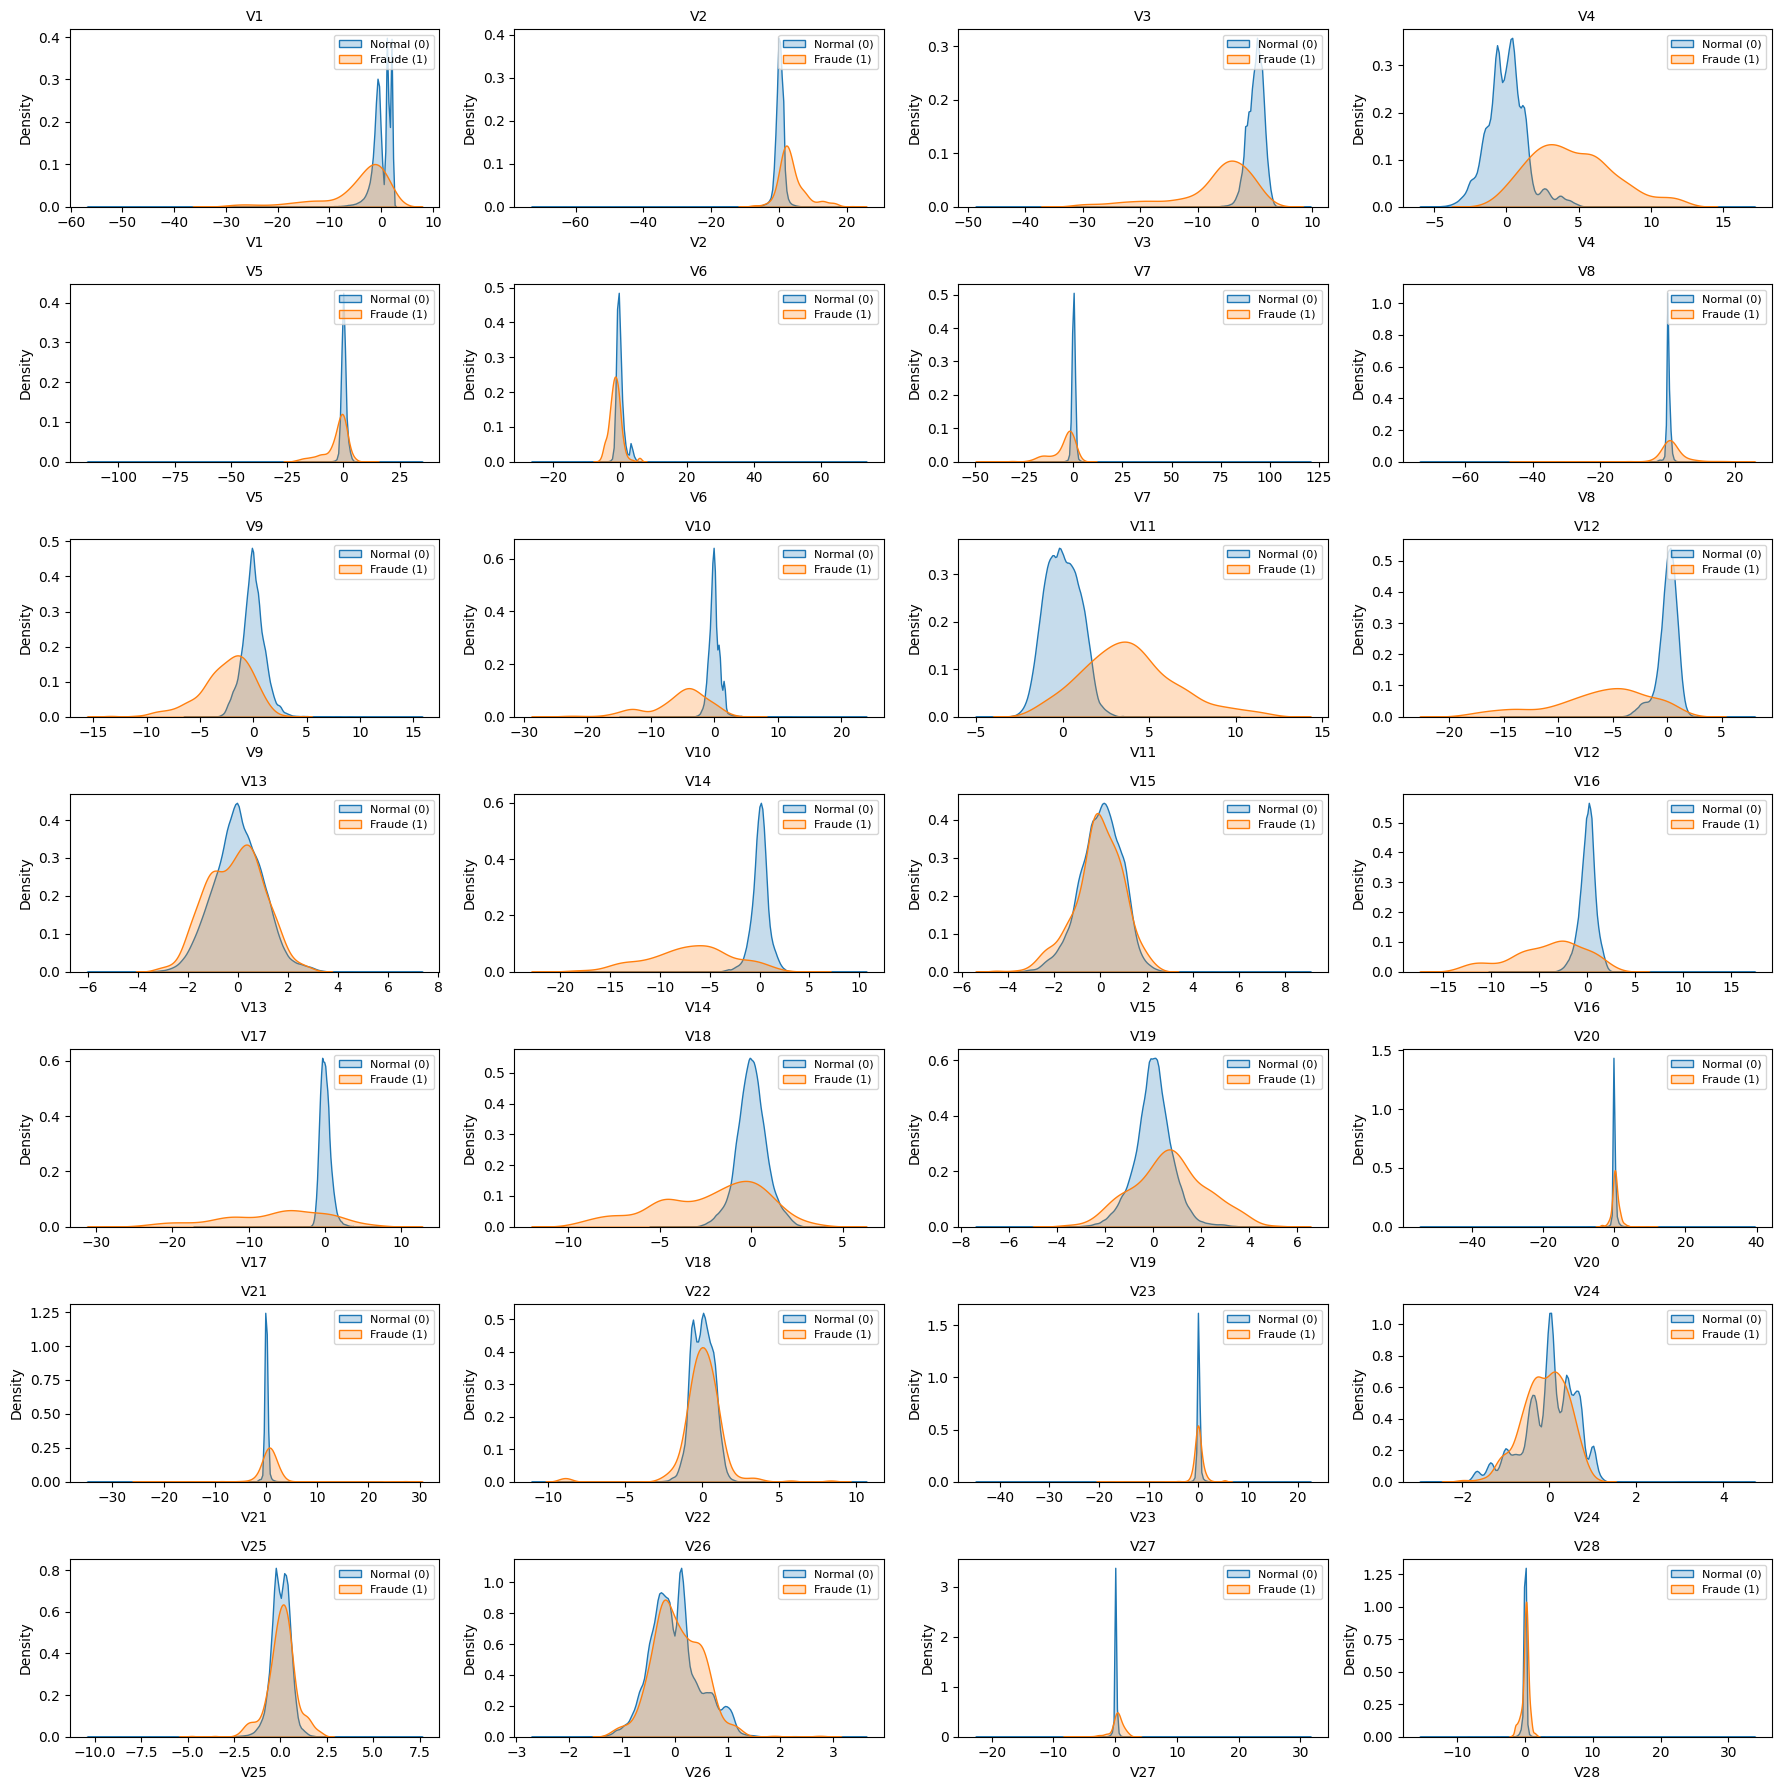

In [91]:
column_names = df.drop(['Class', 'Amount', 'Time'], axis=1).columns
num_plots = len(column_names)
df_class_0 = df[df.Class == 0]
df_class_1 = df[df.Class == 1]

fig, ax = plt.subplots(nrows=7, ncols=4, figsize=(18,18))
fig.subplots_adjust(hspace=1, wspace=1)

idx = 0
for col in column_names:
    idx += 1
    plt.subplot(7, 4, idx)
    sns.kdeplot(df_class_0[col], label="Normal (0)", fill=True)
    sns.kdeplot(df_class_1[col], label="Fraude (1)", fill=True)
    plt.title(col, fontsize=10)
    plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()

O gráfico de densidade é muito útil para compararmos as distribuições de cada variável para cada classe e ver quais as mais importantes para detecção de anomalias.

O que se procura nesse tipo de visualização são distribuições que diferem uma da outra, permitindo identificar fraudes mais facilmente. Veja como exemplo as variáveis `V3`, `V4`, `V6` e `V14`, como elas são bem distintas.

Por outro lado, variáveis como `V13`, `V15`, `V22` e `V26` são muito similares, apresentando aproximadamente o mesmo comportamento.

Resumidamente, algumas observações principais que puderam ser extraídas dessa etapa exploratória foram:

* O *dataset* está muito desbalanceado, uma vez que as transações fraudulentas representam apenas 0,17% das entradas totais.
* Não existem valores ausentes ou nulos no *dataframe*.
* Uma vez que a PCA é sensível à escala das variáveis, assume-se a premissa que as *features* originais foram padronizadas.
* As colunas `Time` e `Amount` não estão normalizadas.

### Preparação dos Dados

Normalizaremos os dados que ainda não haviam sido pré-processados (`Time` e `Amount`)

In [28]:
# Normalizar as variáveis Time e Amount
df_clean = df.copy()

scaler = StandardScaler()

df_clean['std_time'] = scaler.fit_transform(df_clean['Time'].values.reshape(-1,1))
df_clean['std_amount'] = scaler.fit_transform(df_clean['Amount'].values.reshape(-1,1))

df_clean.drop(['Time', 'Amount'], axis=1, inplace=True)

df_clean.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_time,std_amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996562,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-1.996562,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-1.996541,-0.073403


Dividir o conjunto de dados entre treino e teste

In [29]:
# Separar variáveis entre X e y
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Dividir o dataset entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True)

Balancear o conjunto de dados

Class
0    369
1    369
Name: count, dtype: int64


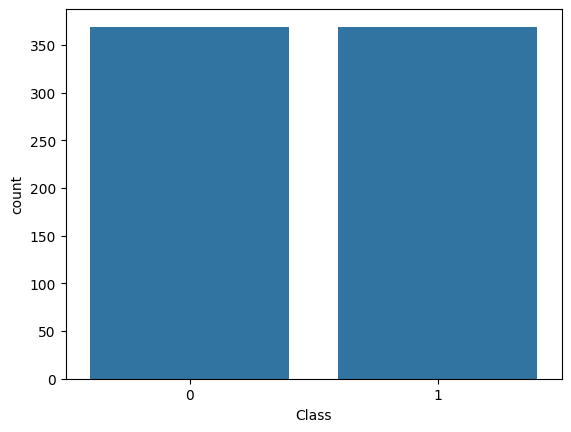

In [32]:
# Uso da técnica de balanceamento under sampling
rus = RandomUnderSampler()

X_rus, y_rus = rus.fit_resample(X_train, y_train)

# Visualizar o balanceamento das classes
print(y_rus.value_counts())

# Plotar a nova distribuição de classes
sns.countplot(x=y_rus);

### Matriz de Correlação para dados Balanceados x Desbalanceados

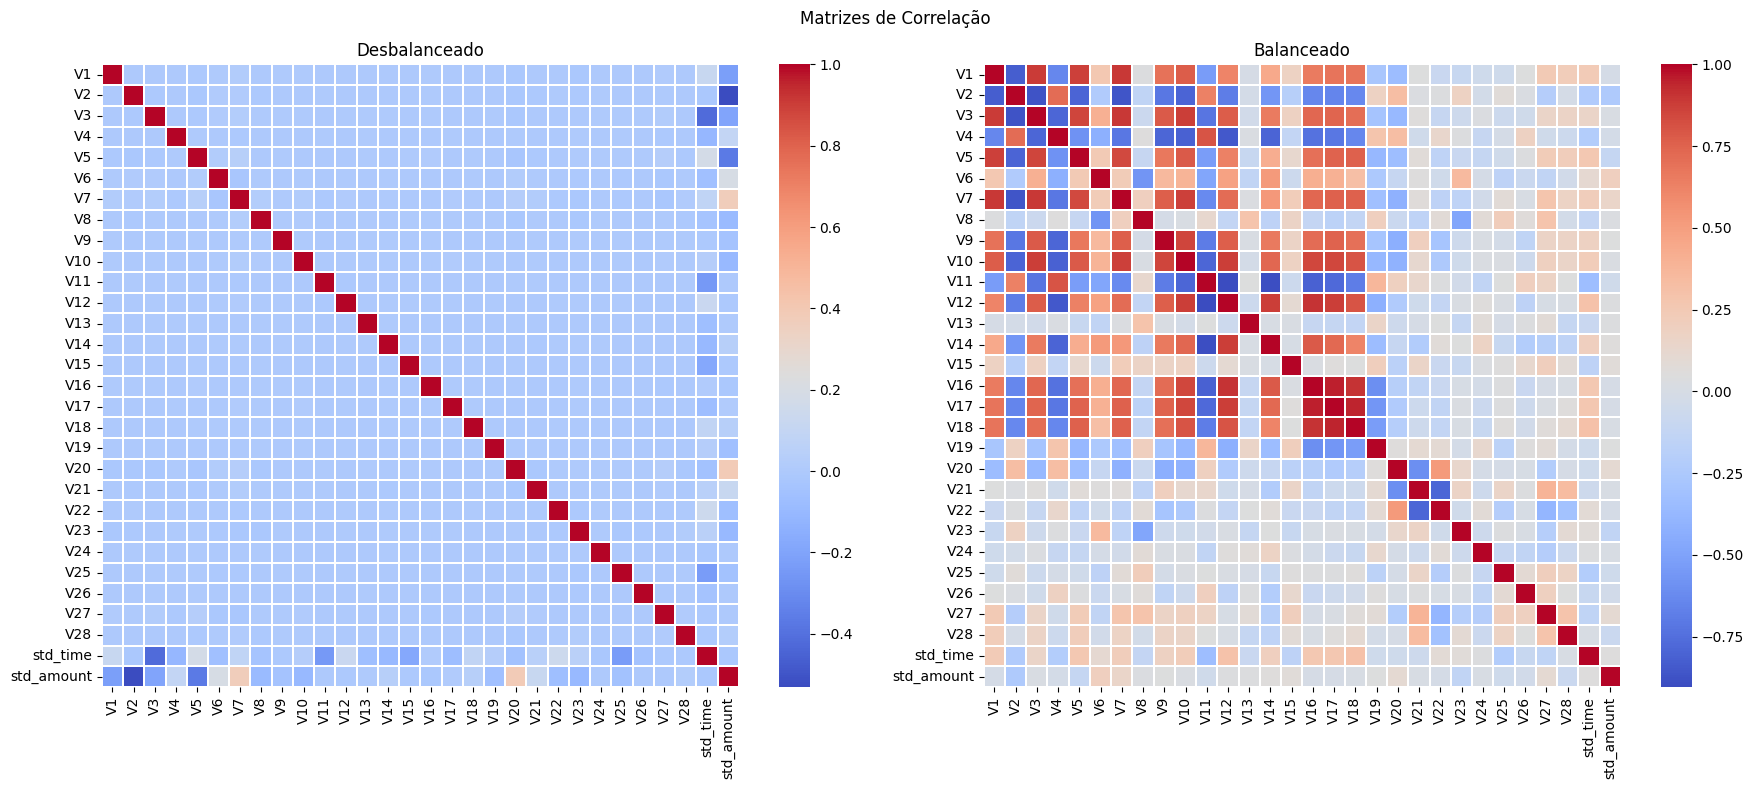

In [36]:
# Plotar as Matrizes de Correlação
corr = X_train.corr()
corr_rus = X_rus.corr()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,8))

plt.suptitle('Matrizes de Correlação')

sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, linewidths=.1, cmap='coolwarm', ax=ax[0])
ax[0].set_title('Desbalanceado')

sns.heatmap(corr_rus, xticklabels=corr_rus.columns, yticklabels=corr_rus.columns, linewidths=.1, cmap='coolwarm', ax=ax[1])
ax[1].set_title('Balanceado')

plt.tight_layout();

Com os dados balanceados, podemos ver a matriz de correlação e identificar quais variáveis estão mais fortemente relacionadas com as outras.

Observe como anteriormente, sem o balanceamento de dados, a matriz de correlação não trazia nenhuma informação relevante. Entretanto, ela traz muito mais informações após um correto balanceamento.

## Modelos de Machine Learning


Com todos os dados preparados e após uma análise exploratória completa, irei construir um classificador usando a Regressão Logística.

Após instanciar o modelo, o mesmo será treinado em cima dos dados em `X_rus` e `y_rus`. Na sequência, serão realizadas as previsões sobre os dados de teste.

### Regressão Logística

In [69]:
# Importar o modelo de Regressão Logística
from sklearn.linear_model import LogisticRegression

# Instanciar esse modelo
lr_model = LogisticRegression()

# Treinar o modelo com os dados de treino balanceados
lr_model.fit(X_rus, y_rus)

LogisticRegression()

In [70]:
# Fazer previsões com a base de teste
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)

Com o modelo treinado e as previsões feitas, parte-se para a avaliação do desempenho.

Neste tipo de problema, originalmente desbalanceado, a acurácia não é uma métrica adequada.

Observe a matriz de confusão para ver a taxa de acertos para transações fraudulentes, ou pela coluna *recall* do Relatório de Classificação.

Uma outra métrica considerada interessante para se avaliar a eficácia é a AUCROC, ou área sob a curva. No caso desse modelo de Regressão Logística, tem-se 95% de AUC.

### Árvore de Decisão

In [74]:
# Importar o modelo de Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier

# Instanciar esse modelo
dt_model = DecisionTreeClassifier()

# Treinar o modelo com os dados de treino balanceados
dt_model.fit(X_rus, y_rus)

DecisionTreeClassifier()

In [75]:
# Fazer previsões com a base de teste
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)

## Avaliações dos desempenhos dos modelos

### Regressão Logística

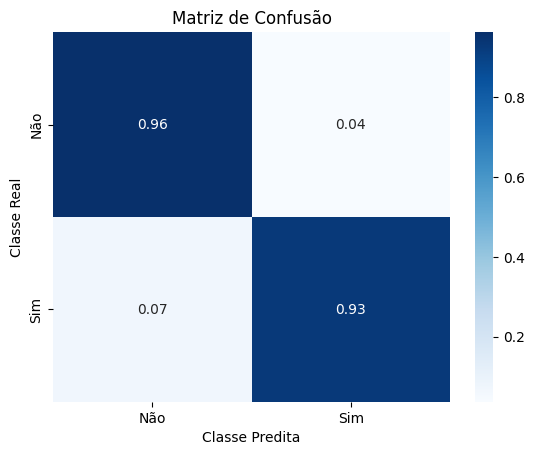

In [78]:
# Avaliação do modelo usando Matriz de Confusão

cm = confusion_matrix(y_test, y_pred_lr, normalize='true')

sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=['Não', 'Sim'],
    yticklabels=['Não', 'Sim']
)

plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show();

In [79]:
# Avaliação do modelo usando classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     71079
           1       0.04      0.93      0.08       123

    accuracy                           0.96     71202
   macro avg       0.52      0.94      0.53     71202
weighted avg       1.00      0.96      0.98     71202



In [81]:
# Avaliação do modelo por meio da acurácia
print(f'Acurácia: {accuracy_score(y_test, y_pred_lr)}')

# Avaliação do modelo por meio da área abaixo da curva ROC
print(f'Área abaixo da curva ROC: {roc_auc_score(y_test, y_pred_lr)}')

Acurácia: 0.9625853206370607
Área abaixo da curva ROC: 0.944738231833422


### Árvore de Decisão

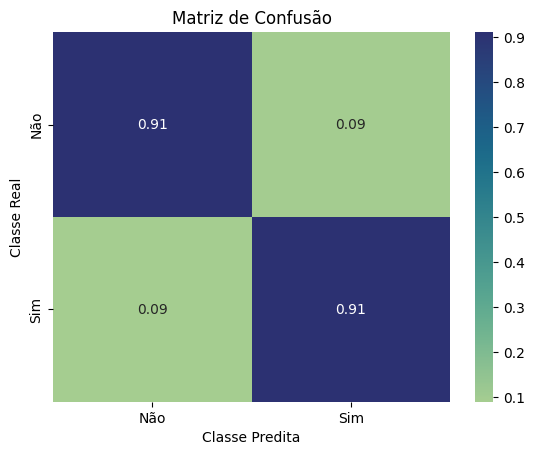

In [88]:
# Avaliação do modelo usando Matriz de Confusão

cm = confusion_matrix(y_test, y_pred_dt, normalize='true')

sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='crest',
    xticklabels=['Não', 'Sim'],
    yticklabels=['Não', 'Sim']
)

plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.show();

In [83]:
# Avaliação do modelo usando classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     71079
           1       0.02      0.91      0.03       123

    accuracy                           0.91     71202
   macro avg       0.51      0.91      0.49     71202
weighted avg       1.00      0.91      0.95     71202



In [84]:
# Avaliação do modelo por meio da acurácia
print(f'Acurácia: {accuracy_score(y_test, y_pred_dt)}')

# Avaliação do modelo por meio da área abaixo da curva ROC
print(f'Área abaixo da curva ROC: {roc_auc_score(y_test, y_pred_dt)}')

Acurácia: 0.9071514845088621
Área abaixo da curva ROC: 0.9088573380563503


## Conclusão

Como pudemos observar, não se trata de um problema trivial. Apesar dos dados estarem bem tratados e limpos, sem valores ausentes ou variáveis categóricas, o desbalanceamento e a Transformação PCA demandaram um trabalho considerável.

Quando comparamos os desempenhos dos algoritmos testados com o conjunto de dados, percebemos que a Regressão Logística performou melhor que a Árvore de Decisão nas métricas analisadas.